[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maierav/madelane26/blob/main/MaDeLaNe26_S1M1_Rasters.ipynb)

# S1 → M1 Connectivity: Rasters & PSTHs from Human ICMS Data
## MaDeLaNe 2026 — Multi-Area High-Density Laminar Neurophysiology

This notebook visualises raw spike data from **Shelchkova et al. (2023)** *Nature Communications*:
*"Microstimulation of human somatosensory cortex evokes task-dependent,
spatially patterned responses in motor cortex"*

**Experiment overview**

| Item | Detail |
|------|--------|
| Participants | 3 humans with spinal-cord injury (BCI clinical trial) |
| Stimulation | ICMS through individual electrodes in S1 (area 1) |
| Recording | Single/multi-unit activity on Utah arrays in M1 |
| Stim parameters | 60 uA, 100 Hz, 1-s trains (20 reps per S1 electrode) |
| Raw data | One `.mat` (HDF5) file per S1-electrode x M1-channel pair |

**Data**: [DABI repository](https://dabi.loni.usc.edu/) — Participant C1, passive-stimulation session 2021-12-28.


In [1]:
# @title 1. Install dependencies & download data
!pip install h5py numpy matplotlib scipy gdown -q

import os

DATA_DIR = "/content/RawData_C1"

if not os.path.isdir(DATA_DIR) or len(os.listdir(DATA_DIR)) == 0:
    import gdown, zipfile

    # Download example data (14 .mat files, ~470 KB) from Google Drive
    file_id = "12sp2uCVmi4RmUntzwzcf5ajK9Sv6C1xd"
    zip_path = "/content/madelane26_example_data.zip"

    gdown.download(id=file_id, output=zip_path, quiet=False)

    if not os.path.exists(zip_path) or os.path.getsize(zip_path) < 1000:
        raise RuntimeError(
            f"Download failed. Please download manually from:\n"
            f"  https://drive.google.com/file/d/{file_id}/view?usp=sharing\n"
            f"and upload the zip to /content/, then re-run this cell.")

    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)

files = os.listdir(DATA_DIR)
print(f"{len(files)} files in {DATA_DIR}")
for f in sorted(files)[:5]:
    print(f"  {f}")
if len(files) > 5:
    print(f"  ... and {len(files)-5} more")


Downloading...
From: https://drive.google.com/uc?id=12sp2uCVmi4RmUntzwzcf5ajK9Sv6C1xd
To: /content/madelane26_example_data.zip
100%|██████████| 480k/480k [00:00<00:00, 2.04MB/s]

14 files in /content/RawData_C1
  SE15_MC138_100Hz_Raw_20211228.mat
  SE1_MC109_100Hz_Raw_20211228.mat
  SE1_MC138_100Hz_Raw_20211228.mat
  SE1_MC139_100Hz_Raw_20211228.mat
  SE1_MC154_100Hz_Raw_20211228.mat
  ... and 9 more


In [2]:
# @title 2. Data loader
import os, h5py, numpy as np

def load_channel_pair(data_dir, stim_elec, motor_ch, freq=100,
                      date="20211228"):
    """Load raw spike + stimulation data for one SE x MC pair."""
    fname = f"SE{stim_elec}_MC{motor_ch}_{freq}Hz_Raw_{date}.mat"
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        available = sorted(os.listdir(data_dir)) if os.path.isdir(data_dir) else []
        raise FileNotFoundError(
            f"Not found: {fpath}\n"
            f"Directory has {len(available)} files: {available[:5]}...")
    with h5py.File(fpath, 'r') as f:
        sm = f['smRaw']
        spike_times = sm['spike']['time'][:].flatten()
        n_trains    = int(sm['stim']['train']['numTrains'][0, 0])
        train_amp   = sm['stim']['train']['amp'][:].flatten()
        train_freq  = sm['stim']['train']['freq'][:].flatten()
        refs = sm['stim']['train']['time'][0]
        train_starts = np.array([f[r][:].flatten()[0] for r in refs])
        train_ends   = np.array([f[r][:].flatten()[-1] for r in refs])
    return dict(spike_times=spike_times, n_trains=n_trains,
                train_starts=train_starts, train_ends=train_ends,
                train_amp=train_amp, train_freq=train_freq,
                stim_elec=stim_elec, motor_ch=motor_ch)

# Quick sanity check
print(f"DATA_DIR: {DATA_DIR}")
print(f"Files: {sorted(os.listdir(DATA_DIR))}")
_test = load_channel_pair(DATA_DIR, 1, 138)
print(f"Test load SE1 x MC138: {len(_test['spike_times'])} spikes -- OK")


DATA_DIR: /content/RawData_C1
Files: ['SE15_MC138_100Hz_Raw_20211228.mat', 'SE1_MC109_100Hz_Raw_20211228.mat', 'SE1_MC138_100Hz_Raw_20211228.mat', 'SE1_MC139_100Hz_Raw_20211228.mat', 'SE1_MC154_100Hz_Raw_20211228.mat', 'SE1_MC163_100Hz_Raw_20211228.mat', 'SE1_MC165_100Hz_Raw_20211228.mat', 'SE1_MC168_100Hz_Raw_20211228.mat', 'SE1_MC175_100Hz_Raw_20211228.mat', 'SE1_MC181_100Hz_Raw_20211228.mat', 'SE1_MC184_100Hz_Raw_20211228.mat', 'SE1_MC47_100Hz_Raw_20211228.mat', 'SE40_MC138_100Hz_Raw_20211228.mat', 'SE40_MC154_100Hz_Raw_20211228.mat']
Test load SE1 x MC138: 893 spikes -- OK


In [3]:
# @title 3. Plotting helpers
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def plot_raster_and_psth(data, window=(-0.5, 1.5), bin_size=0.02,
                         sigma_ms=30, title=None,
                         ax_raster=None, ax_psth=None):
    """Train-aligned raster (top) + PSTH with Gaussian-smoothed SDF (bottom)."""
    sp, ts, nt = data['spike_times'], data['train_starts'], data['n_trains']

    if ax_raster is None or ax_psth is None:
        fig, (ax_raster, ax_psth) = plt.subplots(
            2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])

    all_aligned = []
    for i, t0 in enumerate(ts):
        mask = (sp >= t0 + window[0]) & (sp < t0 + window[1])
        aligned = sp[mask] - t0
        all_aligned.append(aligned)
        ax_raster.scatter(aligned, np.full_like(aligned, i),
                          marker='|', s=18, c='k', linewidths=0.6)

    ax_raster.axvline(0, color='red', ls='--', alpha=0.7, label='Stim onset')
    ax_raster.axvspan(0, 1.0, color='red', alpha=0.08, label='Stim (1 s)')
    ax_raster.set_ylabel('Trial')
    ax_raster.set_ylim(-0.5, nt - 0.5)
    ax_raster.legend(loc='upper right', fontsize=8)
    if title:
        ax_raster.set_title(title, fontsize=12, fontweight='bold')

    all_spikes = np.concatenate(all_aligned)
    bins       = np.arange(window[0], window[1] + bin_size, bin_size)
    counts, be = np.histogram(all_spikes, bins=bins)
    rate       = counts / (bin_size * nt)
    bc         = (be[:-1] + be[1:]) / 2
    sdf        = gaussian_filter1d(rate.astype(float),
                                   sigma=(sigma_ms / 1000) / bin_size)

    ax_psth.bar(bc, rate, width=bin_size, alpha=0.3, color='gray', label='PSTH')
    ax_psth.plot(bc, sdf, 'b-', lw=1.5, label=f'SDF (sigma={sigma_ms} ms)')
    ax_psth.axvline(0, color='red', ls='--', alpha=0.7)
    ax_psth.axvspan(0, 1.0, color='red', alpha=0.08)

    bl_mask = (bc >= window[0]) & (bc < 0)
    if bl_mask.sum() > 0:
        bl = rate[bl_mask].mean()
        ax_psth.axhline(bl, color='green', ls=':', alpha=0.6,
                        label=f'Baseline = {bl:.1f} Hz')

    ax_psth.set_xlabel('Time relative to stim onset (s)')
    ax_psth.set_ylabel('Firing rate (Hz)')
    ax_psth.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    return ax_raster, ax_psth


def plot_pulse_locked(data, window_ms=(-2, 9), bin_size_ms=0.25,
                      max_pulses=600, title=None):
    """Raster + PSTH aligned to individual ICMS pulses (ms timescale).

    The paper discards the first 2 ms post-pulse to avoid stimulation
    artefact.  Short-latency pulse-locked responses at 2-7 ms suggest
    monosynaptic S1 -> M1 connections.
    """
    sp = data['spike_times']
    pulse_times = np.concatenate(
        [t0 + np.arange(100) * 0.01 for t0 in data['train_starts']])

    if len(pulse_times) > max_pulses:
        idx = np.linspace(0, len(pulse_times)-1, max_pulses).astype(int)
        pt = pulse_times[idx]
    else:
        pt = pulse_times

    fig, (ax_r, ax_p) = plt.subplots(
        2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
    ws = (window_ms[0]/1000, window_ms[1]/1000)
    all_aligned = []
    for i, t0 in enumerate(pt):
        mask = (sp >= t0+ws[0]) & (sp < t0+ws[1])
        a_ms = (sp[mask] - t0) * 1000
        all_aligned.append(a_ms)
        ax_r.scatter(a_ms, np.full_like(a_ms, i),
                     marker='|', s=8, c='k', linewidths=0.3)

    ax_r.axvline(0, color='red', alpha=0.7)
    ax_r.axvspan(0, 2, color='gray', alpha=0.2, label='Artefact zone (0-2 ms)')
    ax_r.set_ylabel('Pulse #')
    ax_r.legend(loc='upper right', fontsize=8)
    if title:
        ax_r.set_title(title, fontsize=12, fontweight='bold')

    all_ms = np.concatenate(all_aligned) if all_aligned else np.array([])
    bins = np.arange(window_ms[0], window_ms[1]+bin_size_ms, bin_size_ms)
    if len(all_ms) > 0:
        counts, be = np.histogram(all_ms, bins=bins)
        rate = counts / ((bin_size_ms/1000) * len(pt))
        bc = (be[:-1]+be[1:])/2
        ax_p.bar(bc, rate, width=bin_size_ms, color='steelblue', alpha=0.7)

    ax_p.axvline(0, color='red', alpha=0.7)
    ax_p.axvspan(0, 2, color='gray', alpha=0.2)
    ax_p.set_xlabel('Time relative to pulse (ms)')
    ax_p.set_ylabel('Firing rate (Hz)')
    plt.tight_layout()
    return fig

print("Plotting helpers ready")


Plotting helpers ready


---
## Example 1: Strong excitatory response — SE1 x MC138

MC138 shows a **3-fold rate increase** during S1 stimulation (baseline ~6 Hz ->
stim ~17 Hz). The increase is consistent trial-by-trial and clearly visible in
both the raster and the SDF. This is one of the most reliably modulated M1
channels in this session.


SE1 x MC138: 893 spikes, 20 trains at 60 uA


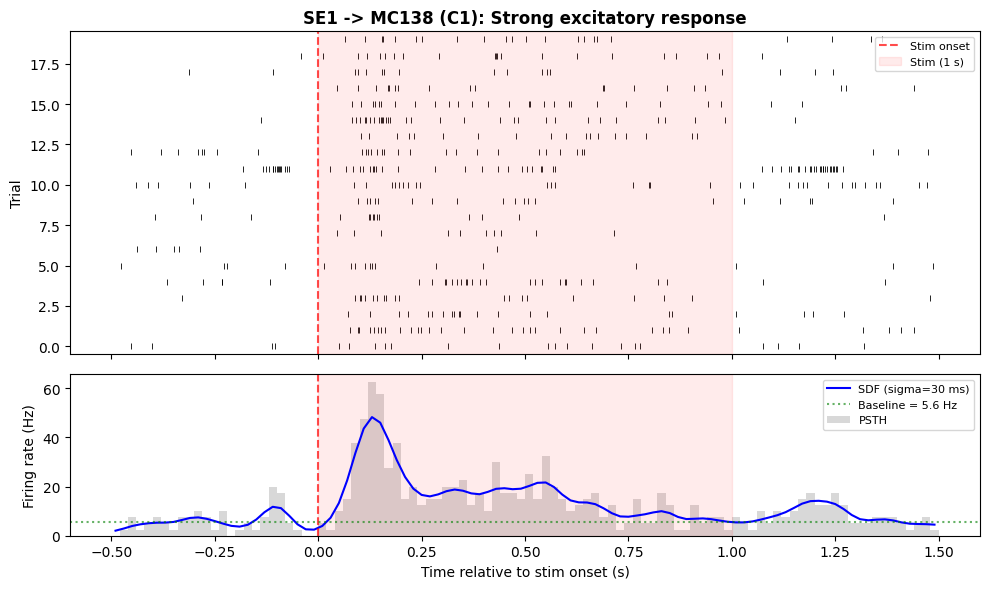

In [4]:
data_mc138 = load_channel_pair(DATA_DIR, stim_elec=1, motor_ch=138)
print(f"SE1 x MC138: {len(data_mc138['spike_times']):,} spikes, "
      f"{data_mc138['n_trains']} trains at {data_mc138['train_amp'][0]:.0f} uA")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
plot_raster_and_psth(data_mc138, title='SE1 -> MC138 (C1): Strong excitatory response',
                     ax_raster=ax1, ax_psth=ax2)
plt.show()


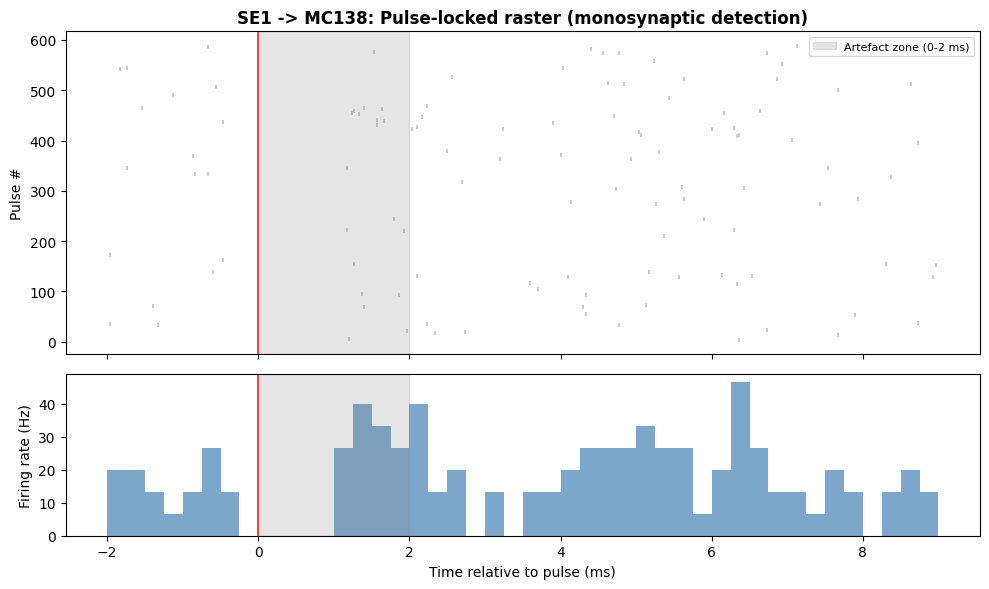

In [5]:
plot_pulse_locked(data_mc138,
    title='SE1 -> MC138: Pulse-locked raster (monosynaptic detection)')
plt.show()


---
## Example 2: Excitatory response with high baseline — SE1 x MC154

MC154 has a higher baseline rate (~21 Hz) and increases to ~38 Hz during
stimulation. The denser raster makes the modulation easy to see — note how
spikes are visibly more packed during the red-shaded stim period on most
trials.


SE1 x MC154: 2,950 spikes


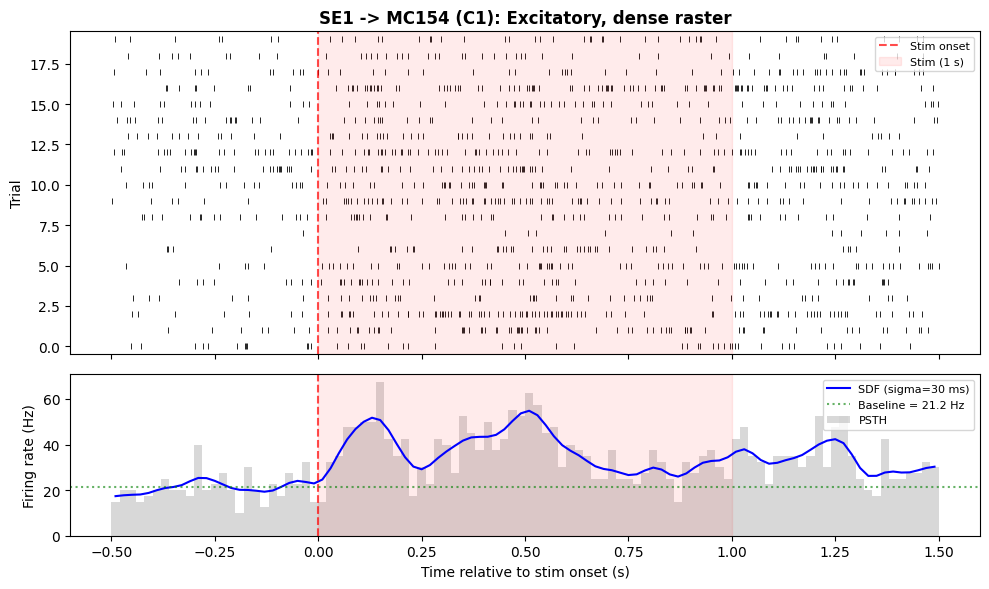

In [6]:
data_mc154 = load_channel_pair(DATA_DIR, stim_elec=1, motor_ch=154)
print(f"SE1 x MC154: {len(data_mc154['spike_times']):,} spikes")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
plot_raster_and_psth(data_mc154, title='SE1 -> MC154 (C1): Excitatory, dense raster',
                     ax_raster=ax1, ax_psth=ax2)
plt.show()


---
## Example 3: Inhibitory response — SE1 x MC175

MC175 shows clear **suppression** during S1 stimulation — firing drops from
~29 Hz to ~22 Hz. This is the most trial-consistent inhibitory channel in
this session. Note the visible thinning of spike marks during the stim window.


SE1 x MC175: 2,694 spikes


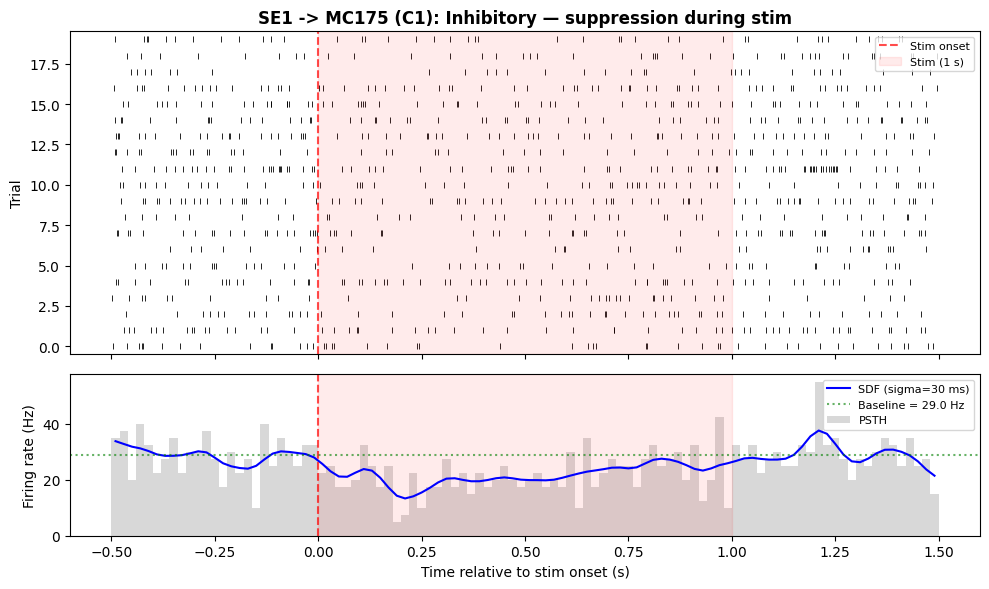

In [7]:
data_mc175 = load_channel_pair(DATA_DIR, stim_elec=1, motor_ch=175)
print(f"SE1 x MC175: {len(data_mc175['spike_times']):,} spikes")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
plot_raster_and_psth(data_mc175, title='SE1 -> MC175 (C1): Inhibitory — suppression during stim',
                     ax_raster=ax1, ax_psth=ax2)
plt.show()


---
## Example 4: Inhibitory response — SE1 x MC165

MC165 shows even stronger inhibition (17 Hz -> 10 Hz, ~40% suppression).
Together with MC175, these demonstrate the paper's finding that S1 ICMS
can *suppress* M1 activity — not just excite it.


SE1 x MC165: 1,582 spikes


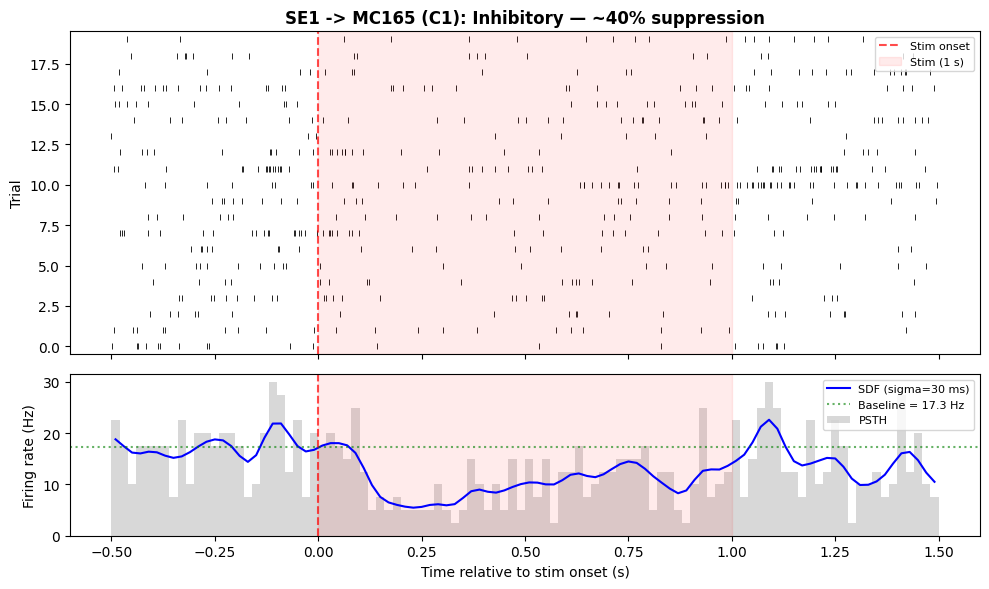

In [8]:
data_mc165 = load_channel_pair(DATA_DIR, stim_elec=1, motor_ch=165)
print(f"SE1 x MC165: {len(data_mc165['spike_times']):,} spikes")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
plot_raster_and_psth(data_mc165, title='SE1 -> MC165 (C1): Inhibitory — ~40% suppression',
                     ax_raster=ax1, ax_psth=ax2)
plt.show()


---
## Somatotopic specificity: Same M1 neuron, different S1 electrodes

A key finding of the paper is that connectivity follows **somatotopic maps**.
Below we stimulate MC138 from three different S1 electrodes:

- **SE1**: 3x rate increase (6 -> 17 Hz)
- **SE15**: even stronger (6 -> 23 Hz)
- **SE40**: **no effect** (10 -> 10 Hz)

This shows that MC138 is selectively driven by certain S1 sites — likely
those with projected fields on the same finger that MC138 encodes movement for.


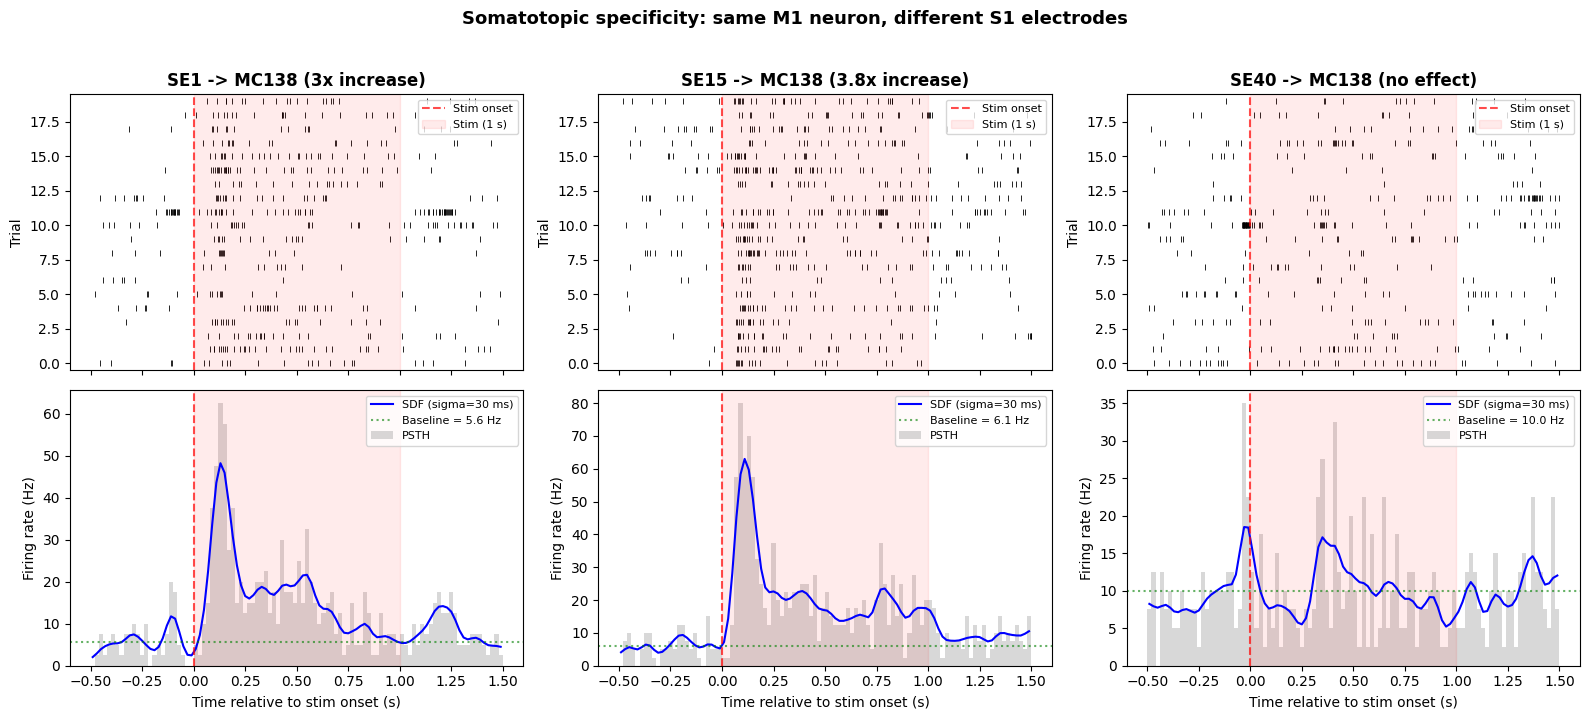

In [9]:
data_se15 = load_channel_pair(DATA_DIR, stim_elec=15, motor_ch=138)
data_se40 = load_channel_pair(DATA_DIR, stim_elec=40, motor_ch=138)

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)

for col, (d, lab) in enumerate([
    (data_mc138, 'SE1 -> MC138 (3x increase)'),
    (data_se15,  'SE15 -> MC138 (3.8x increase)'),
    (data_se40,  'SE40 -> MC138 (no effect)'),
]):
    plot_raster_and_psth(d, title=lab,
                         ax_raster=axes[0, col], ax_psth=axes[1, col])

fig.suptitle('Somatotopic specificity: same M1 neuron, different S1 electrodes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Multi-channel overview: SE1 across M1

SDF for 10 M1 channels during SE1 stimulation, showing the full diversity of
response types: excitation, inhibition, and mixed effects. Channels are ordered
by response type and labeled with baseline -> stim firing rate.


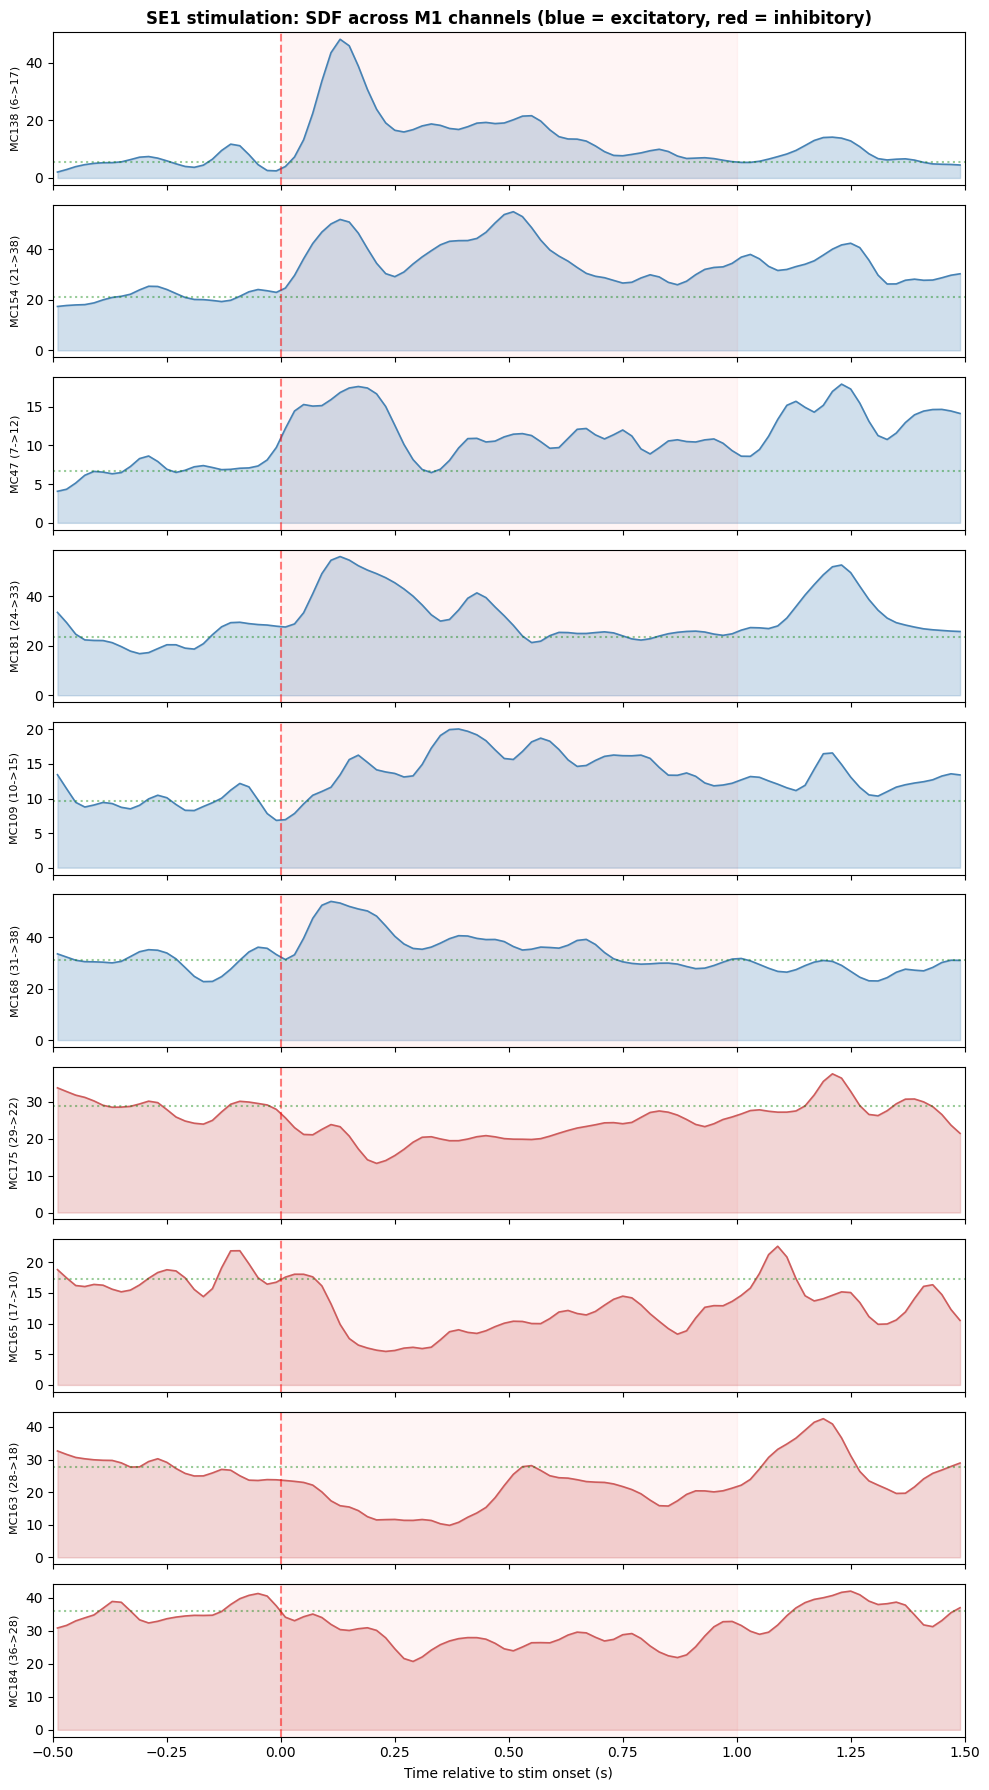

In [10]:
channels = [138, 154, 47, 181, 109, 168, 175, 165, 163, 184]
labels   = ['MC138 (6->17)', 'MC154 (21->38)', 'MC47 (7->12)',
            'MC181 (24->33)', 'MC109 (10->15)', 'MC168 (31->38)',
            'MC175 (29->22)', 'MC165 (17->10)', 'MC163 (28->18)',
            'MC184 (36->28)']
colors   = ['steelblue']*6 + ['indianred']*4  # blue=excit, red=inhib

window   = (-0.5, 1.5)
bin_size = 0.02
sigma_bins = (30 / 1000) / bin_size

fig, axes = plt.subplots(len(channels), 1,
                         figsize=(10, 1.8 * len(channels)), sharex=True)

for idx, (mc, lab, col) in enumerate(zip(channels, labels, colors)):
    try:
        d  = load_channel_pair(DATA_DIR, stim_elec=1, motor_ch=mc)
        sp, ts, nt = d['spike_times'], d['train_starts'], d['n_trains']

        aligned = np.concatenate([
            sp[(sp >= t0+window[0]) & (sp < t0+window[1])] - t0 for t0 in ts])
        bins       = np.arange(window[0], window[1]+bin_size, bin_size)
        counts, be = np.histogram(aligned, bins=bins)
        rate       = counts / (bin_size * nt)
        bc         = (be[:-1]+be[1:])/2
        sdf        = gaussian_filter1d(rate.astype(float), sigma=sigma_bins)

        axes[idx].fill_between(bc, sdf, alpha=0.25, color=col)
        axes[idx].plot(bc, sdf, color=col, lw=1.2)
        axes[idx].axvline(0, color='red', ls='--', alpha=0.5)
        axes[idx].axvspan(0, 1.0, color='red', alpha=0.04)

        bl = rate[(bc>=-0.5)&(bc<0)].mean()
        axes[idx].axhline(bl, color='green', ls=':', alpha=0.4)
        axes[idx].set_ylabel(f'{lab}', fontsize=8)
        axes[idx].set_xlim(window)
    except Exception as e:
        axes[idx].text(0.5, 0.5, str(e), transform=axes[idx].transAxes, fontsize=8)

axes[-1].set_xlabel('Time relative to stim onset (s)')
axes[0].set_title('SE1 stimulation: SDF across M1 channels (blue = excitatory, red = inhibitory)',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Summary

| Response type | Example | Baseline | During stim | Change |
|---------------|---------|----------|-------------|--------|
| **Strong excitation** | MC138 | 6 Hz | 17 Hz | +200% |
| **Moderate excitation** | MC154 | 21 Hz | 38 Hz | +80% |
| **Inhibition** | MC175 | 29 Hz | 22 Hz | -25% |
| **Strong inhibition** | MC165 | 17 Hz | 10 Hz | -40% |
| **Somatotopic** | MC138 via SE15 | 6 Hz | 23 Hz | +280% |
| **No connection** | MC138 via SE40 | 10 Hz | 10 Hz | 0% |

### Key takeaways
- S1 ICMS modulates M1 neurons with both **excitatory and inhibitory** effects
- Effects are **somatotopically specific**: a given M1 neuron is driven by some S1 electrodes but not others
- Response patterns are **heterogeneous** across the M1 array
- The paper further shows these effects are **task-dependent** (not shown here — only passive-condition data in this example set)

### Reference
Shelchkova, N.D., Downey, J.E., Greenspon, C.M. et al. *Microstimulation of human
somatosensory cortex evokes task-dependent, spatially patterned responses in motor cortex.*
Nat Commun **14**, 7368 (2023). [doi:10.1038/s41467-023-43140-2](https://doi.org/10.1038/s41467-023-43140-2)
